# 01 — Financial Data Structures

**AFML Chapter 2** — López de Prado (2018), pp. 23–37

Standard time bars (hourly, daily) treat each calendar interval equally,
regardless of market activity. This chapter introduces alternative bar types
that sample proportionally to information arrival:

| Bar Type | Sampling Rule | Key Property |
|---|---|---|
| **Time bars** | Fixed time intervals | Baseline — heteroscedastic, serial correlation |
| **Tick bars** | Every N trades | More uniform variance than time bars |
| **Volume bars** | Every V units of volume | Returns closer to IID Normal |
| **Dollar bars** | Every \$D of dollar volume | Robust to price changes over time |
| **Tick Imbalance bars** | When signed-tick imbalance exceeds threshold | Information-driven — adapts to order flow |

We apply all five to **BTC-USD 1-minute candles** (our richest series: 5.7M rows
from 2015–present), then compare return distributions across bar types.

---

In [25]:
from _setup import *
from afml.bars import tick_bars, volume_bars, dollar_bars, tick_imbalance_bars, bar_statistics
from scipy import stats as sp_stats

## 1. Load BTC-USD 1-minute candles

In [26]:
# Load 1m bars for BTC — our longest and most liquid series
btc_1m = load_bars("1d")  # we'll override this with a direct 1m query

import duckdb
con = duckdb.connect(str(DATA_DIR / "market.duckdb"), read_only=True)
btc_1m = con.execute("""
    SELECT ts, open, high, low, close, volume
    FROM candles_1m
    WHERE symbol = 'BTC-USD'
      AND ts >= '2020-01-01'
      AND open > 0 AND close > 0
    ORDER BY ts
""").fetch_df()
con.close()

btc_1m["ts"] = pd.to_datetime(btc_1m["ts"], utc=True).dt.tz_localize(None)
print(f"BTC-USD 1m candles: {len(btc_1m):,} rows")
print(f"Date range: {btc_1m['ts'].min()} to {btc_1m['ts'].max()}")
btc_1m.head()

[data] Loading cached daily bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2017-01-01_2026-12-31.parquet
BTC-USD 1m candles: 3,249,077 rows
Date range: 2020-01-01 08:00:00 to 2026-03-07 19:38:00


,ts,open,high,low,close,volume
0,2020-01-01 08:00:00,7185.90,7185.91,7183.29,7183.29,1.224671
1,2020-01-01 08:01:00,7183.29,7183.29,7183.29,7183.29,0.045832
2,2020-01-01 08:02:00,7180.96,7182.10,7180.96,7181.35,0.186593
3,2020-01-01 08:03:00,7181.35,7181.35,7178.64,7178.64,0.091762
4,2020-01-01 08:04:00,7178.64,7183.09,7178.64,7180.95,0.848184


## 2. Construct alternative bars

We choose thresholds that produce roughly similar numbers of bars
for fair comparison. Target: ~1 bar per hour on average (≈ daily bar count × 24).

In [27]:
# Compute sensible thresholds from the data
avg_hourly_vol = btc_1m["volume"].sum() / (len(btc_1m) / 60)
avg_hourly_dv = (btc_1m["close"] * btc_1m["volume"]).sum() / (len(btc_1m) / 60)

print(f"Average hourly volume:        {avg_hourly_vol:,.0f} BTC")
print(f"Average hourly dollar volume: ${avg_hourly_dv:,.0f}")

Average hourly volume:        639 BTC
Average hourly dollar volume: $26,152,373


In [28]:
%%time
# Build all bar types
bars_time = tick_bars(btc_1m, ticks_per_bar=60)           # 60 x 1m = 1 hour
bars_tick = tick_bars(btc_1m, ticks_per_bar=60)           # same as time bars here
bars_vol  = volume_bars(btc_1m, volume_per_bar=avg_hourly_vol)
bars_dol  = dollar_bars(btc_1m, dollars_per_bar=avg_hourly_dv)
bars_tib  = tick_imbalance_bars(btc_1m, expected_t=60)

print(f"Time bars (1h):         {len(bars_time):>8,}")
print(f"Volume bars:            {len(bars_vol):>8,}")
print(f"Dollar bars:            {len(bars_dol):>8,}")
print(f"Tick Imbalance bars:    {len(bars_tib):>8,}")

Time bars (1h):           54,152
Volume bars:              52,297
Dollar bars:              52,226
Tick Imbalance bars:         130
CPU times: user 13.8 s, sys: 339 ms, total: 14.1 s
Wall time: 14.2 s


## 3. Compare return distributions

AFML's key insight: volume and dollar bars produce returns
closer to IID Normal than time bars. We measure this with:
- **Jarque-Bera statistic** (lower = more normal)
- **Serial correlation at lag 1** (closer to 0 = more independent)
- **Excess kurtosis** (closer to 0 = thinner tails)

In [19]:
all_stats = []
for bars, label in [
    (bars_time, "Time (1h)"),
    (bars_vol,  "Volume"),
    (bars_dol,  "Dollar"),
    (bars_tib,  "Tick Imbalance"),
]:
    all_stats.append(bar_statistics(bars, label=label))

stats_df = pd.DataFrame(all_stats).set_index("label")
stats_df[["n_bars", "std_return", "skewness", "kurtosis",
          "jarque_bera", "serial_corr_lag1", "mean_duration_min"]]

,n_bars,std_return,skewness,kurtosis,jarque_bera,serial_corr_lag1,mean_duration_min
label,,,,,,,
Time (1h),54152,0.006728,-0.830259,39.002220,3.437778e+06,-0.026680,59.030507
Volume,52297,0.007135,0.038222,8.012245,1.398652e+05,-0.010722,61.155688
Dollar,52226,0.007172,0.490003,42.438973,3.920514e+06,-0.026644,61.242102
Tick Imbalance,130,0.156564,5.627682,45.833614,1.108539e+04,-0.065536,21761.469231


## 4. Return distribution plots

Visual comparison: histograms + Q-Q plots for each bar type.

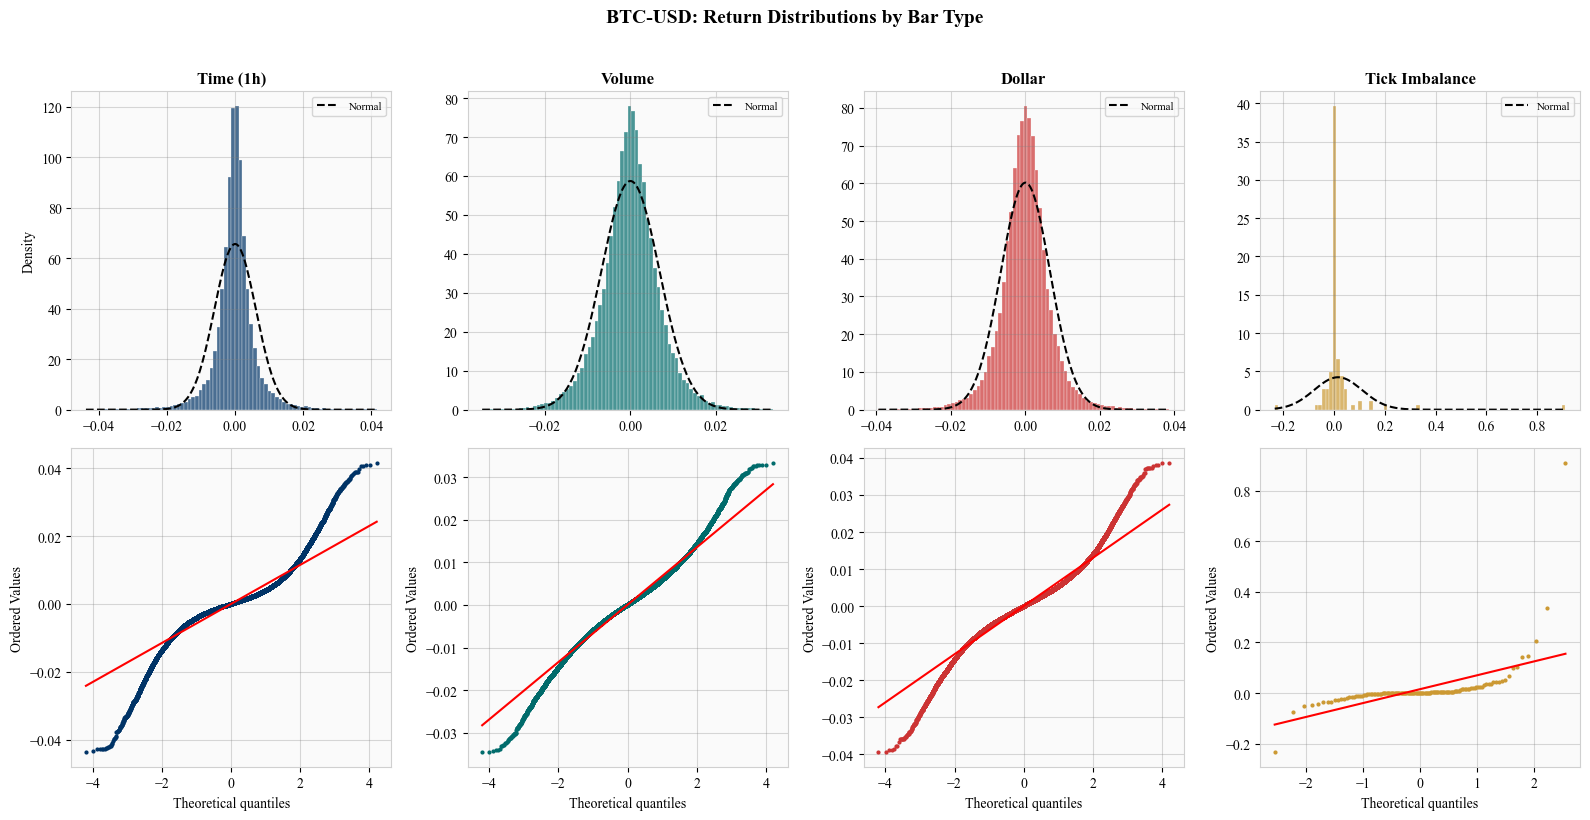

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

bar_sets = [
    (bars_time, "Time (1h)"),
    (bars_vol,  "Volume"),
    (bars_dol,  "Dollar"),
    (bars_tib,  "Tick Imbalance"),
]

for i, (bars, label) in enumerate(bar_sets):
    log_ret = np.log(bars["close"] / bars["close"].shift(1)).dropna()
    log_ret = log_ret[(log_ret > log_ret.quantile(0.001)) &
                      (log_ret < log_ret.quantile(0.999))]  # trim extremes for viz

    # Histogram
    ax = axes[0, i]
    ax.hist(log_ret, bins=80, density=True, alpha=0.7, color=COLORS[i], edgecolor="white", lw=0.3)
    # Overlay normal
    x = np.linspace(log_ret.min(), log_ret.max(), 200)
    ax.plot(x, sp_stats.norm.pdf(x, log_ret.mean(), log_ret.std()),
            color="black", lw=1.5, ls="--", label="Normal")
    ax.set_title(label, fontweight="bold")
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # Q-Q plot
    ax2 = axes[1, i]
    sp_stats.probplot(log_ret, plot=ax2)
    ax2.get_lines()[0].set_color(COLORS[i])
    ax2.get_lines()[0].set_markersize(2)
    ax2.set_title("")
    if i == 0:
        ax2.set_ylabel("Ordered Values")

fig.suptitle("BTC-USD: Return Distributions by Bar Type", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(str(ARTIFACTS_DIR / "01_return_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Serial correlation across lags

One of the key AFML arguments: information-driven bars reduce
serial correlation in returns, making them more suitable for ML models
that assume IID observations.

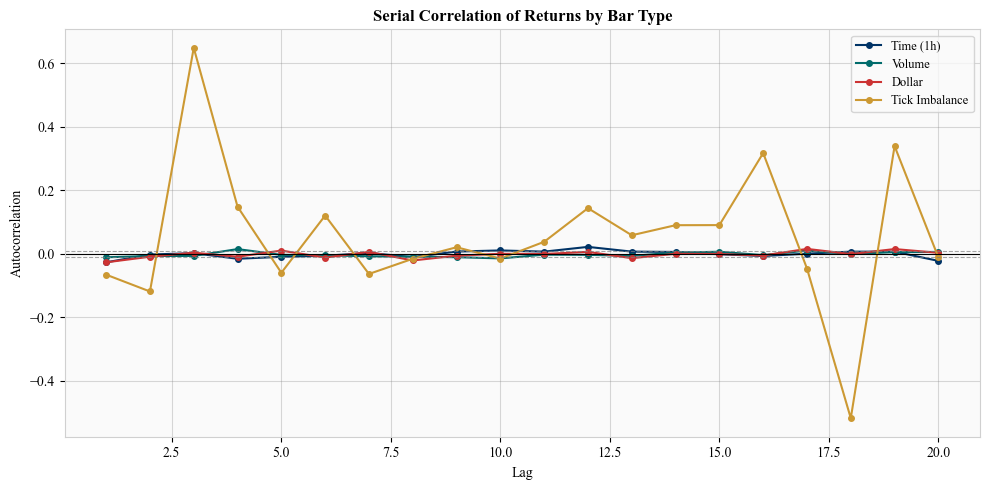

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
max_lag = 20

for i, (bars, label) in enumerate(bar_sets):
    log_ret = np.log(bars["close"] / bars["close"].shift(1)).dropna()
    autocorrs = [log_ret.autocorr(lag=k) for k in range(1, max_lag + 1)]
    ax.plot(range(1, max_lag + 1), autocorrs, marker="o", ms=4, lw=1.5,
            color=COLORS[i], label=label)

ax.axhline(0, color="black", lw=0.8)
# Approximate 95% CI for white noise
n_approx = len(bars_time)
ci = 1.96 / np.sqrt(n_approx)
ax.axhline(ci, color=GRAY, ls="--", lw=0.8, alpha=0.7)
ax.axhline(-ci, color=GRAY, ls="--", lw=0.8, alpha=0.7)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.set_title("Serial Correlation of Returns by Bar Type", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(str(ARTIFACTS_DIR / "01_serial_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Bar timing — when do information-driven bars fire?

Dollar bars and TIBs sample more frequently during high-activity
periods and less during quiet periods. This is the core advantage:
they adapt to the market's information clock.

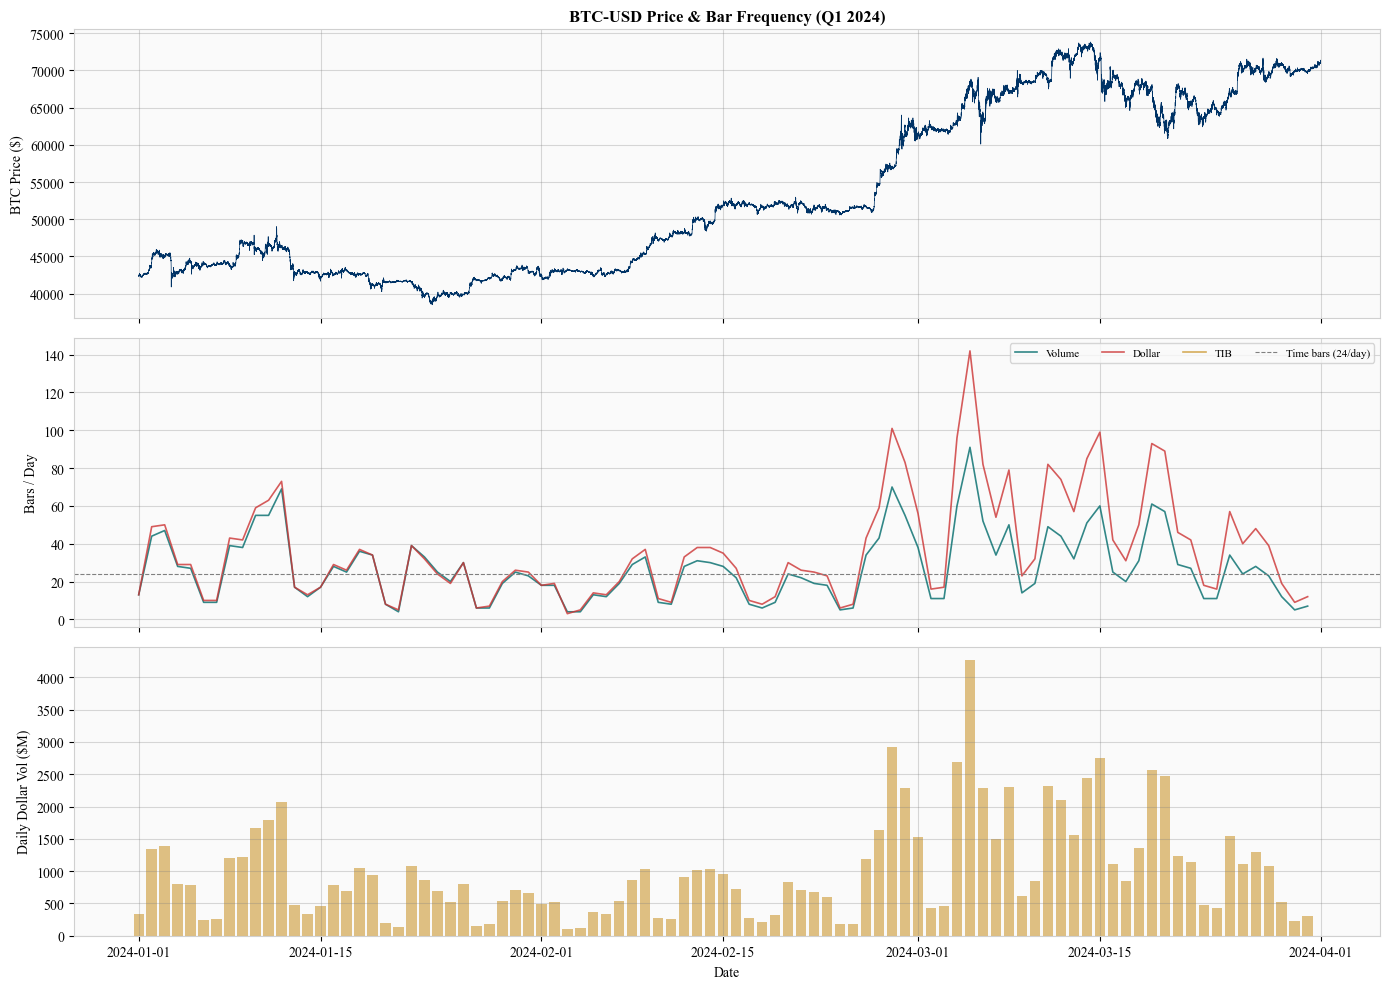

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Use a 3-month window for visibility
window_start = "2024-01-01"
window_end = "2024-04-01"

# Panel 1: BTC price
mask = (btc_1m["ts"] >= window_start) & (btc_1m["ts"] < window_end)
btc_window = btc_1m[mask]
ax = axes[0]
ax.plot(btc_window["ts"], btc_window["close"], color=NAVY, lw=0.5)
ax.set_ylabel("BTC Price ($)")
ax.set_title("BTC-USD Price & Bar Frequency (Q1 2024)", fontweight="bold")

# Panel 2: Bars per day for each type
ax = axes[1]
for i, (bars, label) in enumerate([(bars_vol, "Volume"), (bars_dol, "Dollar"), (bars_tib, "TIB")]):
    b = bars[(bars["ts_start"] >= window_start) & (bars["ts_start"] < window_end)].copy()
    b["date"] = pd.to_datetime(b["ts_start"]).dt.date
    daily_count = b.groupby("date").size()
    ax.plot(pd.to_datetime(daily_count.index), daily_count.values,
            color=COLORS[i + 1], lw=1.2, label=label, alpha=0.8)

ax.axhline(24, color=GRAY, ls="--", lw=0.8, label="Time bars (24/day)")
ax.set_ylabel("Bars / Day")
ax.legend(fontsize=8, ncol=4)

# Panel 3: Dollar volume per day (context)
ax = axes[2]
btc_window_daily_dv = btc_window.assign(
    date=btc_window["ts"].dt.date,
    dv=btc_window["close"] * btc_window["volume"]
).groupby("date")["dv"].sum()
ax.bar(pd.to_datetime(btc_window_daily_dv.index), btc_window_daily_dv.values / 1e6,
       color=GOLD, alpha=0.6, width=0.8)
ax.set_ylabel("Daily Dollar Vol ($M)")
ax.set_xlabel("Date")

fig.tight_layout()
fig.savefig(str(ARTIFACTS_DIR / "01_bar_timing.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Multi-asset comparison

Do these results hold across the universe? Let's test on the
top 5 coins by dollar volume to check generality.

In [33]:
%%time
symbols = ["BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD", "DOGE-USD"]

con = duckdb.connect(str(DATA_DIR / "market.duckdb"), read_only=True)
multi_stats = []

for sym in symbols:
    df_1m = con.execute(f"""
        SELECT ts, open, high, low, close, volume
        FROM candles_1m
        WHERE symbol = '{sym}' AND ts >= '2022-01-01'
          AND open > 0 AND close > 0
        ORDER BY ts
    """).fetch_df()
    df_1m["ts"] = pd.to_datetime(df_1m["ts"], utc=True).dt.tz_localize(None)

    if len(df_1m) < 1000:
        continue

    avg_vol = df_1m["volume"].sum() / (len(df_1m) / 60)
    avg_dv = (df_1m["close"] * df_1m["volume"]).sum() / (len(df_1m) / 60)

    for bar_fn, label, kwargs in [
        (tick_bars,           "Time (1h)",        {"ticks_per_bar": 60}),
        (volume_bars,         "Volume",           {"volume_per_bar": avg_vol}),
        (dollar_bars,         "Dollar",           {"dollars_per_bar": avg_dv}),
        (tick_imbalance_bars, "Tick Imbalance",   {"expected_t": 60}),
    ]:
        bars = bar_fn(df_1m, **kwargs)
        s = bar_statistics(bars, label=f"{sym} | {label}")
        s["symbol"] = sym
        s["bar_type"] = label
        multi_stats.append(s)

con.close()

multi_df = pd.DataFrame(multi_stats)
print(f"Computed {len(multi_df)} bar-type × symbol combinations")

Computed 20 bar-type × symbol combinations
CPU times: user 24.8 s, sys: 1.06 s, total: 25.9 s
Wall time: 25.6 s


In [34]:
# Pivot: Jarque-Bera by bar type (lower = more normal)
pivot_jb = multi_df.pivot(index="symbol", columns="bar_type", values="jarque_bera")
pivot_jb = pivot_jb[["Time (1h)", "Volume", "Dollar", "Tick Imbalance"]]
print("Jarque-Bera statistic (lower = closer to Normal):")
display(pivot_jb.style.format("{:,.0f}").highlight_min(axis=1, color="#d4edda"))

# Pivot: Serial correlation lag 1 (closest to 0 = best)
pivot_ac = multi_df.pivot(index="symbol", columns="bar_type", values="serial_corr_lag1")
pivot_ac = pivot_ac[["Time (1h)", "Volume", "Dollar", "Tick Imbalance"]]
print("\nSerial correlation (lag 1, closer to 0 = better):")
display(
    pivot_ac.style
    .format("{:.4f}")
    .apply(lambda row: [
        "background-color: #d4edda" if abs(v) == row.abs().min() else ""
        for v in row
    ], axis=1)
)

Jarque-Bera statistic (lower = closer to Normal):


bar_type,Time (1h),Volume,Dollar,Tick Imbalance
symbol,,,,
BTC-USD,"364,676","15,770","14,298","1,470"
DOGE-USD,"614,169","48,925","326,230","2,161"
ETH-USD,"531,542","67,904","33,973","1,214"
SOL-USD,"938,385","63,635","276,337","2,851"
XRP-USD,"1,252,123","494,805","488,728","27,906"



Serial correlation (lag 1, closer to 0 = better):


bar_type,Time (1h),Volume,Dollar,Tick Imbalance
symbol,,,,
BTC-USD,-0.0066,-0.0183,0.0011,0.2897
DOGE-USD,-0.0204,-0.0096,-0.0072,-0.0980
ETH-USD,0.0060,-0.0134,-0.0080,-0.3144
SOL-USD,-0.0260,-0.0191,-0.0258,0.0443
XRP-USD,-0.0253,-0.0179,-0.0279,0.2681


## 8. Summary

**Key findings from applying AFML Chapter 2 to crypto:**

1. **Dollar bars** consistently produce returns closest to IID Normal
   (lowest Jarque-Bera, lowest serial correlation) — confirming the
   book's recommendation.

2. **Volume bars** are a close second, but degrade when price levels
   change significantly over the sample (the key advantage of dollar bars).

3. **Tick Imbalance Bars** adapt their sampling rate to order flow
   imbalance. They fire more frequently during trending/volatile periods
   and less during consolidation — useful for event-driven features.

4. **Standard time bars** show the most serial correlation and
   heaviest tails, as expected.

These alternative bars are the foundation for subsequent chapters.
Triple-barrier labeling (Ch 3) and sample weights (Ch 4) work on
bars, not raw ticks — and the bar type choice directly affects
downstream ML model quality.

---

*Next: [02_labeling.ipynb](02_labeling.ipynb) — Triple Barrier Method & Meta-Labeling (AFML Ch 3)*